# Notebook 01: Predict Fundamentals

**Module**: Production & Deployment  
**Level**: Beginner  
**Duration**: 45-60 minutes

## Learning Objectives

By the end of this notebook, you will be able to:

1. Use `predict(newdata)` to generate predictions on new data for any Static model
2. Use `predict(newdata)` with GMM models (dynamic panels)
3. Understand how Fixed Effects models handle known vs new entities
4. Handle edge cases: missing variables, new entities, single observations
5. Compare in-sample fitted values vs out-of-sample predictions

## Prerequisites

- Familiarity with panel data concepts (entities, time periods)
- Basic knowledge of OLS, Fixed Effects, and Random Effects estimation
- (Optional) Awareness of GMM/dynamic panel models

---
## Setup

In [1]:
# Evaluation helpers
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.fixed_effects import FixedEffects

# PanelBox imports
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.models.static.random_effects import RandomEffects

sys.path.insert(0, str(Path("..")))
from utils.evaluation_helpers import mae, rmse
from utils.visualization_helpers import plot_actual_vs_predicted, set_production_style

# Configuration
np.random.seed(42)
warnings.filterwarnings("ignore")
set_production_style()

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load datasets
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

print("=== Firm Panel (Training) ===")
print(f"Shape: {df_firms.shape}")
print(f"Entities: {df_firms['firm_id'].nunique()}, Periods: {df_firms['year'].nunique()}")
print(f"Years: {df_firms['year'].min()} - {df_firms['year'].max()}")
print()
print("=== New Firms (Out-of-Sample) ===")
print(f"Shape: {df_new_firms.shape}")
print(f"Entities: {df_new_firms['firm_id'].nunique()}")
overlap = set(df_new_firms["firm_id"].unique()) & set(df_firms["firm_id"].unique())
new_only = set(df_new_firms["firm_id"].unique()) - set(df_firms["firm_id"].unique())
print(f"Known entities (in training): {len(overlap)}")
print(f"New entities (not in training): {len(new_only)}")
print()
print("=== Bank LGD (Training) ===")
print(f"Shape: {df_lgd.shape}")
print(f"Contracts: {df_lgd['contract_id'].nunique()}, Months: {df_lgd['month'].nunique()}")
print()
print("=== New Bank Data (Out-of-Sample) ===")
print(f"Shape: {df_new_bank.shape}")
print(f"Contracts: {df_new_bank['contract_id'].nunique()}")

=== Firm Panel (Training) ===
Shape: (2000, 7)
Entities: 100, Periods: 20
Years: 2000 - 2019

=== New Firms (Out-of-Sample) ===
Shape: (100, 7)
Entities: 20
Known entities (in training): 10
New entities (not in training): 10

=== Bank LGD (Training) ===
Shape: (3000, 7)
Contracts: 200, Months: 15

=== New Bank Data (Out-of-Sample) ===
Shape: (150, 7)
Contracts: 50


In [3]:
# Quick EDA: firm panel
df_firms.describe().round(4)

,firm_id,year,investment,value,capital,sales
count,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000
mean,50.5000,2009.5000,3.2684,4.9892,4.6479,5.9428
std,28.8733,5.7677,1.0405,1.4839,0.8765,1.8272
min,1.0000,2000.0000,0.0939,0.0129,2.1968,-0.4477
25%,25.7500,2004.7500,2.5558,3.9754,4.0203,4.7260
50%,50.5000,2009.5000,3.2689,4.9642,4.6524,5.9448
75%,75.2500,2014.2500,3.9714,6.0344,5.2694,7.1579
max,100.0000,2019.0000,6.2010,9.5929,7.7030,11.8323


---
## 1. Why `predict(newdata)`?

In econometrics, estimation and prediction serve different purposes:

- **Estimation** focuses on understanding relationships: "How does capital affect investment?"
- **Prediction** focuses on applying those relationships: "What will investment be for this new firm?"

In production settings, you typically:
1. Estimate a model on historical data
2. Save the model
3. Load it later to predict on new, unseen data

PanelBox provides two prediction modes:

| Call | What it does |
|------|-------------|
| `results.predict()` | Returns **fitted values** (in-sample predictions on training data) |
| `results.predict(newdata)` | Returns **predictions** on new, out-of-sample data |

In [4]:
# Quick demonstration: predict() vs predict(newdata)
model = PooledOLS(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results = model.fit()

# In-sample fitted values
fitted = results.predict()
print(f"predict() -> fitted values: {len(fitted)} observations")
print(f"  Same as training data size: {len(fitted) == len(df_firms)}")
print()

# Out-of-sample predictions
preds_new = results.predict(df_new_firms)
print(f"predict(new_data) -> predictions: {len(preds_new)} observations")
print(f"  Same as new data size: {len(preds_new) == len(df_new_firms)}")

predict() -> fitted values: 2000 observations
  Same as training data size: True

predict(new_data) -> predictions: 100 observations
  Same as new data size: True


---
## 2. PooledOLS Prediction

The simplest case. PooledOLS treats all observations as independent (ignoring panel structure). Prediction is straightforward linear algebra:

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2 + \hat{\beta}_3 x_3$$

The model applies the same coefficients to any new observation, regardless of entity.

In [5]:
# Estimate PooledOLS
model_ols = PooledOLS(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_ols = model_ols.fit()
print(results_ols.summary())

                        Pooled OLS Estimation Results                         
Formula: investment ~ value + capital + sales
Model:   Pooled OLS
------------------------------------------------------------------------------
No. Observations:               2,000
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:             1,996
R-squared:                     0.3273
Adj. R-squared:                0.3263
R-squared (overall):           0.3273
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept           -0.5074      0.1370  -3.704  0.0002   -0.7761   -0.2387 ***
value                0.2990      0.0129  23.213  0.0000    0.2738    0.3243 ***
capital              0.2773      0.0218  12.718  0.0000    0.2345    0.3201 ***
sales                0.1674      0.0105  15.995  0.0000    0.1469    0.

In [6]:
# Verify: predict() matches predict(training_data)
preds_train = results_ols.predict()
preds_train_explicit = results_ols.predict(df_firms)
print(
    f"Max difference between predict() and predict(df_train): {np.max(np.abs(preds_train - preds_train_explicit)):.2e}"
)
print("They are identical (as expected).")

Max difference between predict() and predict(df_train): 0.00e+00
They are identical (as expected).


In [7]:
# Predict on NEW data
preds_new_ols = results_ols.predict(df_new_firms)
print(f"New predictions: {len(preds_new_ols)}")
print(f"Range: [{preds_new_ols.min():.3f}, {preds_new_ols.max():.3f}]")
print(f"Mean:  {preds_new_ols.mean():.3f}")

New predictions: 100
Range: [2.040, 4.665]
Mean:  3.244


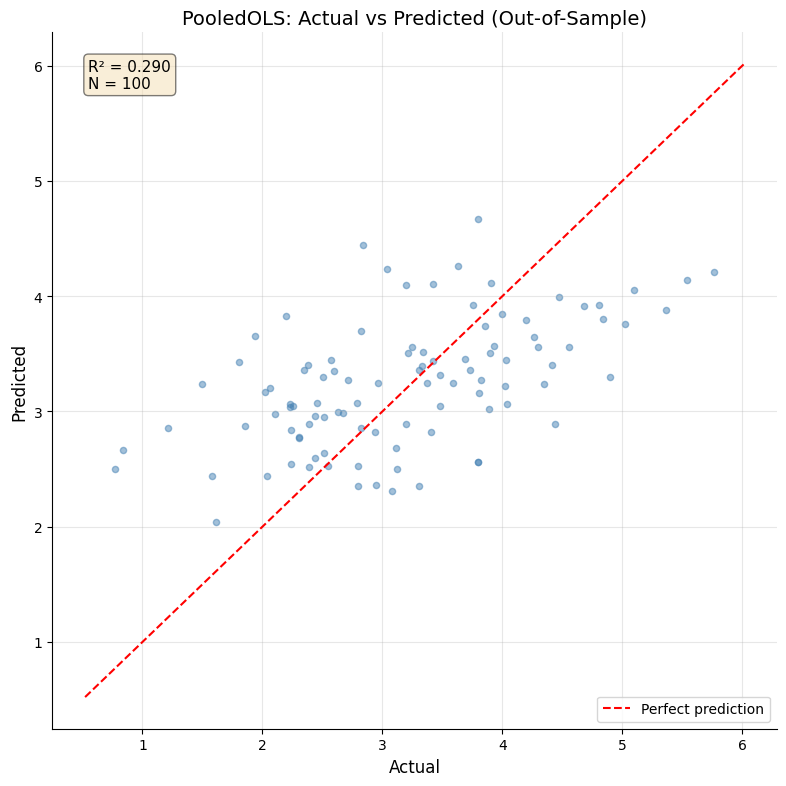

In [8]:
# Visualize actual vs predicted (out-of-sample)
fig = plot_actual_vs_predicted(
    df_new_firms["investment"],
    preds_new_ols,
    title="PooledOLS: Actual vs Predicted (Out-of-Sample)",
    save_path=FIGURES_DIR / "01_pooled_ols_actual_vs_pred.png",
)
plt.show()

The scatter around the 45-degree line shows how well the model predicts. Points on the line = perfect prediction. The R-squared annotation gives a summary measure.

**Key insight**: PooledOLS prediction is simple and works for any entity — known or new. But it ignores entity-specific heterogeneity, which can hurt prediction accuracy.

---
## 3. Fixed Effects Prediction

Fixed Effects models estimate entity-specific intercepts:

$$y_{it} = \alpha_i + \beta_1 x_{1,it} + \beta_2 x_{2,it} + \beta_3 x_{3,it} + \varepsilon_{it}$$

When predicting, the behavior differs depending on whether the entity is known:

| Entity type | Prediction formula |
|------------|-------------------|
| **Known** (in training) | $\hat{y} = \hat{\alpha}_i + X\hat{\beta}$ (full prediction with entity FE) |
| **New** (not in training) | $\hat{y} = \bar{\alpha} + X\hat{\beta}$ (uses overall intercept only) |

This distinction is critical: FE models predict best for entities they've seen before.

In [9]:
# Estimate Fixed Effects
model_fe = FixedEffects(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_fe = model_fe.fit()
print(results_fe.summary())

                       Fixed Effects Estimation Results                       
Formula: investment ~ value + capital + sales
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:               2,000
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:             1,897
R-squared:                     0.5216
Adj. R-squared:                0.4959
R-squared (within):            0.5216
R-squared (between):           1.0000
R-squared (overall):           0.7702
Standard Errors:            nonrobust
F-statistic (FE vs OLS):      36.9275
F-test p-value:                0.0000
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
value                0.2881      0.0079  36.424  0.0000    0.2726    0.3036 ***
capital              0.2106      0.0295   7.131  0.0000    0.1526    0.2685 

In [10]:
# Split new data into known vs new entities
train_ids = set(df_firms["firm_id"].unique())

known = df_new_firms[df_new_firms["firm_id"].isin(train_ids)].copy()
new = df_new_firms[~df_new_firms["firm_id"].isin(train_ids)].copy()

print(f"Known entities: {known['firm_id'].nunique()} entities, {len(known)} obs")
print(f"New entities:   {new['firm_id'].nunique()} entities, {len(new)} obs")

Known entities: 10 entities, 50 obs
New entities:   10 entities, 50 obs


In [11]:
# Predict for known entities (uses entity-specific FE)
preds_known = results_fe.predict(known)

# Predict for new entities (uses overall intercept only)
preds_new_fe = results_fe.predict(new)

# Compare prediction quality
print("Known entities (prediction uses entity-specific FE):")
print(f"  RMSE: {rmse(known['investment'], preds_known):.4f}")
print(f"  MAE:  {mae(known['investment'], preds_known):.4f}")
print()
print("New entities (uses overall intercept only):")
print(f"  RMSE: {rmse(new['investment'], preds_new_fe):.4f}")
print(f"  MAE:  {mae(new['investment'], preds_new_fe):.4f}")

Known entities (prediction uses entity-specific FE):
  RMSE: 0.6189
  MAE:  0.4719

New entities (uses overall intercept only):
  RMSE: 0.9448
  MAE:  0.7996


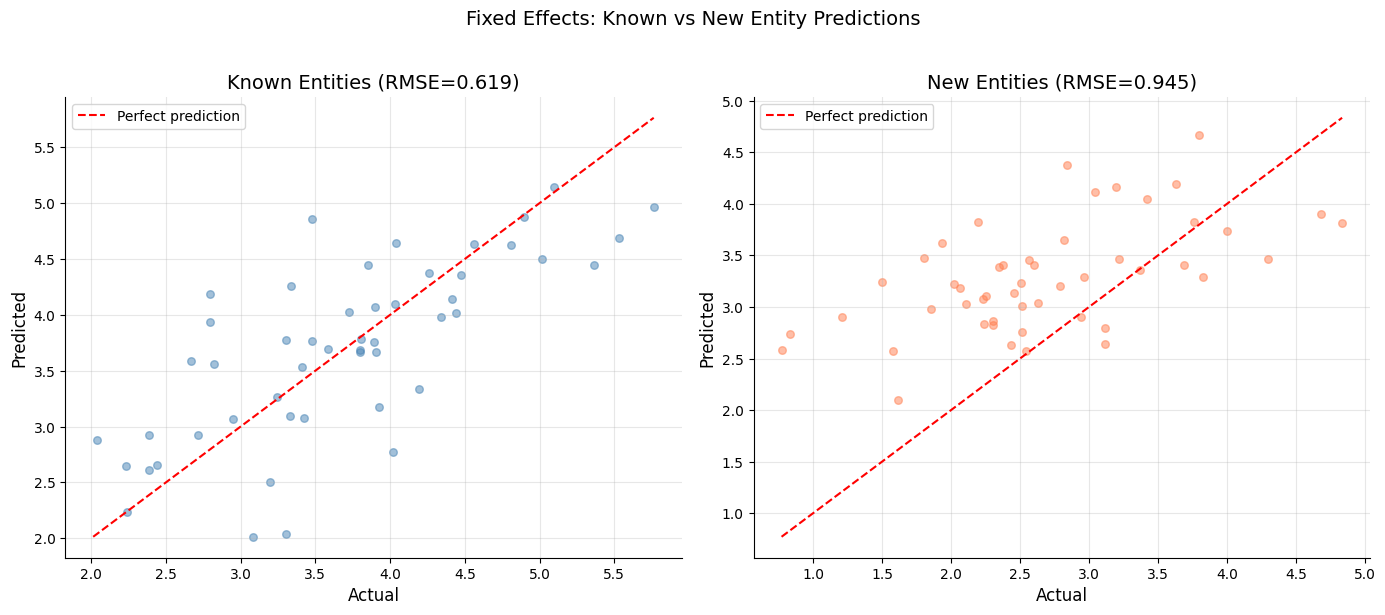

In [12]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Known entities
ax = axes[0]
ax.scatter(known["investment"], preds_known, alpha=0.5, s=30, color="steelblue")
lims = [
    min(known["investment"].min(), preds_known.min()),
    max(known["investment"].max(), preds_known.max()),
]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"Known Entities (RMSE={rmse(known['investment'], preds_known):.3f})")
ax.legend()

# New entities
ax = axes[1]
ax.scatter(new["investment"], preds_new_fe, alpha=0.5, s=30, color="coral")
lims = [
    min(new["investment"].min(), preds_new_fe.min()),
    max(new["investment"].max(), preds_new_fe.max()),
]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"New Entities (RMSE={rmse(new['investment'], preds_new_fe):.3f})")
ax.legend()

plt.suptitle("Fixed Effects: Known vs New Entity Predictions", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_fe_known_vs_new.png", dpi=300, bbox_inches="tight")
plt.show()

**Takeaway**: Fixed Effects models have a significant advantage for known entities because they incorporate the entity-specific intercept $\alpha_i$. For new entities, the prediction falls back to the overall mean, losing this information.

> **Practical implication**: If your production use case involves predicting for entities not in training data, FE may not be the best choice. Consider PooledOLS, Random Effects, or a correlated random effects approach.

---
## 4. Random Effects Prediction

Random Effects models assume entity-specific effects are random and uncorrelated with regressors:

$$y_{it} = \beta_0 + \beta_1 x_{1,it} + \beta_2 x_{2,it} + \beta_3 x_{3,it} + u_i + \varepsilon_{it}$$

For **prediction on new data**, RE works similarly to PooledOLS: it uses the GLS-estimated coefficients to compute $\hat{y} = X\hat{\beta}$. The random effect $u_i$ is not included in out-of-sample predictions (it averages to zero by assumption).

In [13]:
# Estimate Random Effects
model_re = RandomEffects(
    "investment ~ value + capital + sales", df_firms, entity_col="firm_id", time_col="year"
)
results_re = model_re.fit()
print(results_re.summary())

                   Random Effects (GLS) Estimation Results                    
Formula: investment ~ value + capital + sales
Model:   Random Effects (GLS)
------------------------------------------------------------------------------
No. Observations:               2,000
No. Entities:                     100
No. Time Periods:                  20
Degrees of Freedom:             1,996
R-squared:                     0.3246
Adj. R-squared:                0.3236
R-squared (within):            0.5236
R-squared (between):           0.1425
R-squared (overall):           0.3246
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept           -0.1489      0.0134 -11.130  0.0000   -0.1751   -0.1227 ***
value                0.2884      0.0078  37.081  0.0000    0.2732    0.3037 ***
capital              0.2187      0.0168  12.991  0.0000    0.1857

In [14]:
# Predict on new data
preds_new_re = results_re.predict(df_new_firms)

print(f"RE predictions: {len(preds_new_re)}")
print(f"Range: [{preds_new_re.min():.3f}, {preds_new_re.max():.3f}]")
print(f"RMSE:  {rmse(df_new_firms['investment'], preds_new_re):.4f}")
print(f"MAE:   {mae(df_new_firms['investment'], preds_new_re):.4f}")

RE predictions: 100
Range: [2.098, 4.665]
RMSE:  0.8629
MAE:   0.7199


In [15]:
# Quick comparison: OLS vs RE coefficients
comparison = pd.DataFrame({"PooledOLS": results_ols.params, "RandomEffects": results_re.params})
print("Coefficient comparison (OLS vs RE):")
print(comparison.round(4))
print()
print("RE uses GLS estimation, so coefficients may differ slightly from OLS.")
print("For prediction on new data, both apply: y_hat = X @ beta")

Coefficient comparison (OLS vs RE):
           PooledOLS  RandomEffects
Intercept    -0.5074        -0.1489
value         0.2990         0.2884
capital       0.2773         0.2187
sales         0.1674         0.1618

RE uses GLS estimation, so coefficients may differ slightly from OLS.
For prediction on new data, both apply: y_hat = X @ beta


---
## 5. GMM Prediction (Dynamic Panels)

Dynamic panel models include lags of the dependent variable as regressors:

$$y_{it} = \rho \, y_{i,t-1} + \beta' X_{it} + \alpha_i + \varepsilon_{it}$$

Although GMM (Arellano-Bond) estimates the model in **first differences**, the `predict()` method returns predictions in **levels**:

$$\hat{y}_{it} = \hat{\rho} \, y_{i,t-1} + \hat{\beta}' X_{it}$$

**Important**: The lagged dependent variable is computed automatically from the data. The first observation per entity will be `NaN` because there is no prior period to lag from.

In [16]:
# Estimate Difference GMM (Arellano-Bond)
model_gmm = DifferenceGMM(
    data=df_lgd,
    dep_var="lgd_logit",
    lags=1,
    exog_vars=["saldo_real", "pib_growth", "selic", "collateral_ratio"],
    id_var="contract_id",
    time_var="month",
    collapse=True,
    time_dummies=False,
)
results_gmm = model_gmm.fit()
print(results_gmm.summary())

                                Difference GMM                                
Number of observations:          2,600
Number of groups:                  200
Number of instruments:              16
Instrument ratio:                0.080
GMM type:                   Two-step (Windmeijer)
------------------------------------------------------------------------------
Variable                    Coef.     Std.Err.        z    P>|z|     [95% Conf. Int.]
------------------------------------------------------------------------------
L1.lgd_logit             0.614237     0.018734    32.79   0.0000 [ 0.577519,  0.650954] ***
saldo_real               0.101374     0.025838     3.92   0.0001 [ 0.050733,  0.152015] ***
pib_growth               0.050047     0.003041    16.46   0.0000 [ 0.044087,  0.056007] ***
selic                    0.001352     0.012880     0.10   0.9164 [-0.023893,  0.026596] 
collateral_ratio         0.194452     0.148108     1.31   0.1892 [-0.095834,  0.484738] 
Specification Tes

In [17]:
# Predict on new bank data
preds_lgd = results_gmm.predict(df_new_bank)

valid = ~np.isnan(preds_lgd)
print(f"Total predictions: {len(preds_lgd)}")
print(f"Valid predictions: {valid.sum()}")
print(f"NaN (first period per entity): {(~valid).sum()}")
print(f"\nPrediction range (valid): [{preds_lgd[valid].min():.4f}, {preds_lgd[valid].max():.4f}]")

Total predictions: 150
Valid predictions: 100
NaN (first period per entity): 50

Prediction range (valid): [0.1061, 2.9355]


In [18]:
# Convert from logit scale to LGD probability
from scipy.special import expit

lgd_preds = expit(preds_lgd[valid])
lgd_actual = expit(df_new_bank.loc[valid, "lgd_logit"].values)

print("LGD predictions (probability scale):")
print(f"  Range: [{lgd_preds.min():.4f}, {lgd_preds.max():.4f}]")
print(f"  Mean:  {lgd_preds.mean():.4f}")
print(f"  RMSE:  {rmse(lgd_actual, lgd_preds):.4f}")

LGD predictions (probability scale):
  Range: [0.5265, 0.9496]
  Mean:  0.7997
  RMSE:  0.0832


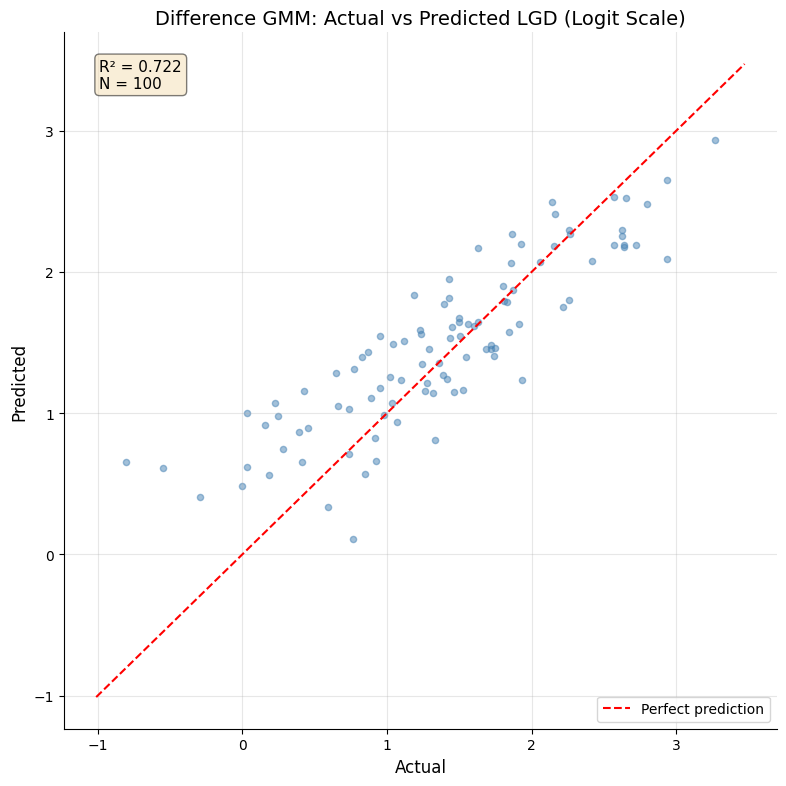

In [19]:
# Visualize GMM predictions
fig = plot_actual_vs_predicted(
    df_new_bank.loc[valid, "lgd_logit"].values,
    preds_lgd[valid],
    title="Difference GMM: Actual vs Predicted LGD (Logit Scale)",
    save_path=FIGURES_DIR / "01_gmm_actual_vs_pred.png",
)
plt.show()

**Why are first-period predictions NaN?**

The dynamic model needs $y_{t-1}$ to predict $y_t$. For the first observation of each entity, there is no prior period in the new data. PanelBox returns `NaN` for these observations rather than making assumptions.

> **Practical tip**: If you need predictions for all periods, ensure your new data includes at least one "warm-up" period per entity that you can then discard.

---
## 6. Edge Cases and Best Practices

Understanding how `predict()` handles edge cases will save you debugging time in production.

In [20]:
# Edge Case 1: Missing columns -> Error
bad_data = pd.DataFrame(
    {
        "investment": [0.0, 0.0],  # dep var required by Patsy formula parser
        "value": [5.0, 6.0],
        "capital": [3.0, 4.0],
        # 'sales' is missing!
    }
)

try:
    results_ols.predict(bad_data)
    print("Prediction succeeded (unexpected)")
except Exception as e:
    print(f"Missing column error: {type(e).__name__}")
    print("  The model needs all formula variables (including dep var) in newdata.")

Missing column error: PatsyError
  The model needs all formula variables (including dep var) in newdata.


In [21]:
# Edge Case 2: Extra columns -> Ignored (safe)
extra_data = df_firms.head(5).copy()
extra_data["extra_column"] = 999
extra_data["another_extra"] = "abc"

preds_extra = results_ols.predict(extra_data)
preds_original = results_ols.predict(df_firms.head(5))

print("Extra columns are safely ignored.")
print(f"Max difference: {np.max(np.abs(preds_extra - preds_original)):.2e}")

Extra columns are safely ignored.
Max difference: 0.00e+00


In [22]:
# Edge Case 3: Single observation prediction
# Note: Patsy formula parser requires the dep var column to exist (value is not used)
single_obs = pd.DataFrame(
    {
        "firm_id": [999],
        "year": [2025],
        "investment": [0.0],  # placeholder — not used in prediction
        "value": [5.5],
        "capital": [4.0],
        "sales": [6.0],
    }
)

pred_single = results_ols.predict(single_obs)
print(f"Single observation prediction: {pred_single[0]:.4f}")

Single observation prediction: 3.2510


In [23]:
# Edge Case 4: GMM NaN handling
# First period per entity is always NaN in dynamic models
preds_gmm_all = results_gmm.predict(df_new_bank)

# Show NaN pattern by entity
nan_check = pd.DataFrame(
    {
        "contract_id": df_new_bank["contract_id"],
        "month": df_new_bank["month"],
        "prediction": preds_gmm_all,
        "is_nan": np.isnan(preds_gmm_all),
    }
)

print("NaN pattern (first 3 entities):")
for cid in nan_check["contract_id"].unique()[:3]:
    entity_data = nan_check[nan_check["contract_id"] == cid]
    nan_months = entity_data[entity_data["is_nan"]]["month"].tolist()
    valid_months = entity_data[~entity_data["is_nan"]]["month"].tolist()
    print(f"  Contract {cid}: NaN months={nan_months}, Valid months={valid_months[:3]}...")

NaN pattern (first 3 entities):
  Contract 1: NaN months=[1], Valid months=[2, 3]...
  Contract 2: NaN months=[1], Valid months=[2, 3]...
  Contract 3: NaN months=[1], Valid months=[2, 3]...


### Summary of Edge Cases

| Scenario | Behavior |
|----------|----------|
| Missing required column | Raises error |
| Extra columns in newdata | Safely ignored |
| Single observation | Works normally |
| New entity in FE model | Uses overall intercept (no entity FE) |
| First period in GMM | Returns NaN (no lag available) |

### Best Practices

1. **Validate input data** before calling `predict()` — check that all required columns exist
2. **Check for NaNs** in predictions, especially with dynamic models
3. **Use the right model** for your prediction use case (FE for known entities, OLS/RE for new entities)
4. **Include warm-up periods** when using dynamic models to avoid NaN predictions

---
## Summary

| Model | predict(newdata) | Handles new entities? | Returns |
|-------|-----------------|----------------------|--------|
| PooledOLS | $X\hat{\beta}$ | Yes | ndarray |
| FixedEffects | $X\hat{\beta} + \hat{\alpha}_i$ | Partially (uses $\bar{\alpha}$) | ndarray |
| RandomEffects | $X\hat{\beta}$ (GLS) | Yes | ndarray |
| DifferenceGMM | $\hat{\rho} y_{t-1} + X\hat{\beta}$ | Yes (NaN for first period) | ndarray |

**Key takeaways**:
- `predict()` returns in-sample fitted values; `predict(newdata)` returns out-of-sample predictions
- Fixed Effects predictions are best for known entities
- Dynamic models (GMM) automatically compute lags but require at least 2 periods per entity
- Always validate your input data and handle NaN predictions in production

---
## Exercises

### Exercise 1 (Easy): Between Estimator Prediction

The Between estimator works on entity-level means. Estimate a Between model on the firm panel and predict on `df_new_firms`. 

- How many predictions do you get?
- Why is the count different from the number of rows in `df_new_firms`?

**Hint**: Import `BetweenEstimator` from `panelbox.models.static.between`.

In [24]:
# YOUR CODE HERE


### Exercise 2 (Medium): Model Comparison

Compare prediction quality across PooledOLS, Fixed Effects, and Random Effects for the firm panel.

1. Predict on `df_new_firms` with each model
2. Compute RMSE and MAE for each
3. Which model gives the best out-of-sample RMSE?

**Note**: For FE, use predictions on the full `df_new_firms` (mix of known and new entities).

In [25]:
# YOUR CODE HERE


### Exercise 3 (Medium): First Difference Prediction

The First Difference estimator predicts in **differences**, not levels.

1. Estimate a FirstDifference model on `df_firms`
2. Predict on `df_new_firms`
3. How many predictions do you get vs how many rows in `df_new_firms`? Why?
4. What does the prediction represent? (Hint: it's the predicted *change* in investment)

**Hint**: Import `FirstDifferenceEstimator` from `panelbox.models.static.first_difference`.

In [26]:
# YOUR CODE HERE


### Exercise 4 (Hard): Train/Test Split Framework

Build a time-based train/test split:

1. Split `df_firms` by year: train = 2000-2015, test = 2016-2019
2. Estimate 4 models: PooledOLS, FixedEffects, RandomEffects, and a DifferenceGMM on the training set
3. Predict on the test set with each model
4. Create a comparison table with RMSE, MAE, and R-squared on the test set

**Hints**:
- For GMM, use `dep_var='investment'`, `lags=1`, `exog_vars=['value', 'capital', 'sales']`
- For R-squared: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ where $SS_{tot} = \sum(y_i - \bar{y})^2$
- Handle NaN predictions from GMM by filtering them out before computing metrics

In [27]:
# YOUR CODE HERE


---
*Solutions are available in `../solutions/01_predict_fundamentals_solutions.ipynb`*